# Module 5 — Estimation, Maximum Likelihood & Confidence Intervals

**Statistics Deep Dive · Notebook 5 of 13**

Module 4 showed that every statistic computed from a sample is a random variable. Now we turn that insight into a working toolkit: how do we *construct* good estimators, how do we *judge* them, and how do we attach an honest **margin of error** to the result?

### 🎯 Learning goals
After this module you can …
1. judge an estimator by its **bias, variance and mean squared error** (and finally see why we divide by $n-1$),
2. derive and compute **maximum-likelihood estimates**, analytically and numerically,
3. build and correctly interpret **confidence intervals** for means, proportions and differences,
4. explain why the textbook (Wald) interval for proportions fails and what to use instead,
5. use the **bootstrap** for statistics that have no formula,
6. distinguish a confidence interval from a **prediction interval**.

### 🗺️ Contents
1. What makes an estimator good? · 2. Efficiency & robustness · 3. Maximum likelihood · 4. Confidence interval for a mean · 5. Proportions: Wald vs. Wilson · 6. Differences between groups · 7. The bootstrap · 8. Confidence vs. prediction intervals · 9. Exercises · 10. Takeaways

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

# --- additional tools for this module ---
from scipy.optimize import minimize, minimize_scalar
from statsmodels.stats.proportion import proportion_confint

---
## 1. What makes an estimator good?

An **estimator** $\hat\theta$ is a recipe that turns a sample into a guess for an unknown population quantity $\theta$ (the *estimand*). The number you get for one concrete sample is the **estimate**. Because the sample is random, $\hat\theta$ has a sampling distribution, and we judge the recipe by that distribution:

| Property | Definition | Plain language |
|---|---|---|
| **Bias** | $\operatorname{Bias}(\hat\theta) = E[\hat\theta] - \theta$ | does the recipe aim at the right spot *on average*? |
| **Variance** | $\operatorname{Var}(\hat\theta) = E\big[(\hat\theta - E[\hat\theta])^2\big]$ | how much do repeated estimates scatter? |
| **Mean squared error** | $\operatorname{MSE} = E[(\hat\theta-\theta)^2] = \operatorname{Bias}^2 + \operatorname{Var}$ | total expected miss — the quantity we actually care about |
| **Consistency** | $\hat\theta \to \theta$ as $n\to\infty$ | more data eventually gets you to the truth |

The decomposition $\text{MSE} = \text{Bias}^2 + \text{Variance}$ is the famous **bias–variance trade-off**: a slightly biased estimator with much smaller variance can beat an unbiased one. The dartboard picture makes this concrete — each red dot is the estimate from one hypothetical sample, the cross is the truth.

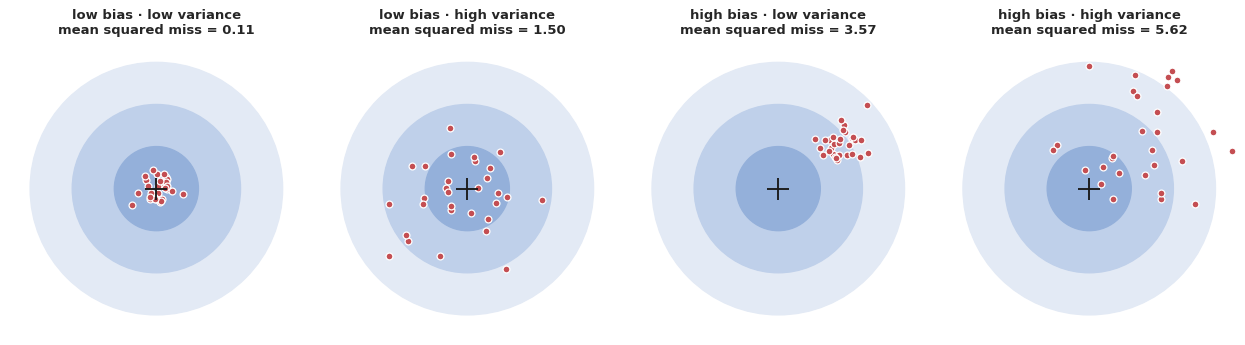

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.9))
cases = [("low bias · low variance", (0, 0), .3), ("low bias · high variance", (0, 0), 1.1),
         ("high bias · low variance", (1.5, 1.1), .3), ("high bias · high variance", (1.5, 1.1), 1.1)]
for ax, (title, centre, sd) in zip(axes, cases):
    for r, col in zip([3, 2, 1], ["#e3eaf5", "#bfd0ea", "#94b0da"]):
        ax.add_patch(plt.Circle((0, 0), r, color=col, zorder=0))
    pts = rng.normal(centre, sd, size=(30, 2))
    ax.scatter(pts[:, 0], pts[:, 1], color=C[3], s=30, edgecolor="white", zorder=3)
    ax.scatter(0, 0, marker="+", s=300, color="k", zorder=4)
    mse = ((pts ** 2).sum(1)).mean()
    ax.set(xlim=(-3.5, 3.5), ylim=(-3.5, 3.5), aspect="equal", xticks=[], yticks=[])
    ax.set_frame_on(False)
    ax.set_title(f"{title}\nmean squared miss = {mse:.2f}", fontsize=10.5)
plt.tight_layout(); plt.show()

### 1.1 The promised proof by simulation: why $n-1$?

We draw many samples from a population with **known** variance $\sigma^2 = 4$ and compare two recipes: dividing the sum of squared deviations by $n$ or by $n-1$.

> 🤔 **Predict first:** which recipe is unbiased? And which one has the smaller *mean squared error*? (The two answers are not the same!)

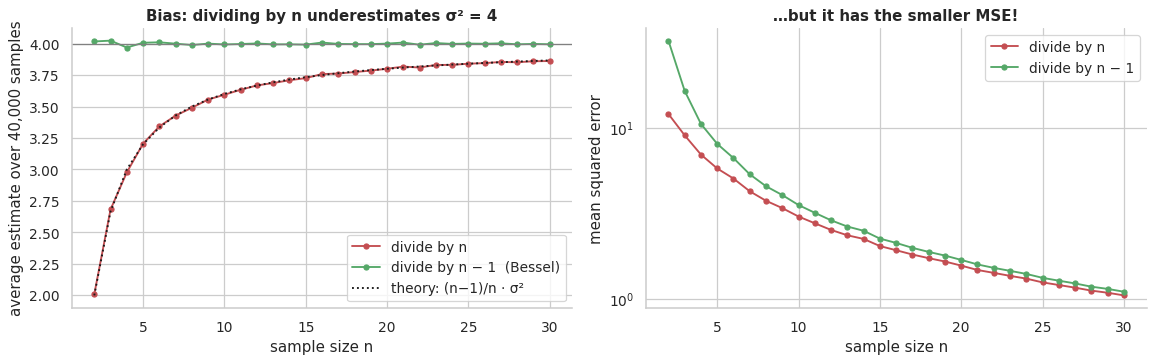

In [3]:
sigma2, ns, R = 4.0, np.arange(2, 31), 40_000
res = []
for n in ns:
    x = rng.normal(10, np.sqrt(sigma2), size=(R, n))
    v_n, v_n1 = x.var(axis=1, ddof=0), x.var(axis=1, ddof=1)
    res.append([v_n.mean(), v_n1.mean(), ((v_n - sigma2) ** 2).mean(), ((v_n1 - sigma2) ** 2).mean()])
res = np.array(res)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2))
a1.plot(ns, res[:, 0], "o-", color=C[3], ms=4, label="divide by n")
a1.plot(ns, res[:, 1], "o-", color=C[2], ms=4, label="divide by n − 1  (Bessel)")
a1.plot(ns, (ns - 1) / ns * sigma2, "k:", label="theory: (n−1)/n · σ²")
a1.axhline(sigma2, color="grey", lw=1); a1.set(xlabel="sample size n", ylabel="average estimate over 40,000 samples", title="Bias: dividing by n underestimates σ² = 4"); a1.legend()
a2.plot(ns, res[:, 2], "o-", color=C[3], ms=4, label="divide by n"); a2.plot(ns, res[:, 3], "o-", color=C[2], ms=4, label="divide by n − 1")
a2.set(xlabel="sample size n", ylabel="mean squared error", yscale="log", title="…but it has the smaller MSE!"); a2.legend()
plt.tight_layout(); plt.show()

**Reading the figure.** *Left:* dividing by $n$ is biased downwards by exactly the factor $(n-1)/n$ — the sample mean is, by construction, the point closest to the sample, so deviations from $\bar x$ are systematically smaller than deviations from the true $\mu$. One **degree of freedom** has been "used up" by estimating the mean. *Right:* the biased estimator nevertheless has the smaller MSE, because shrinking reduces variance more than it adds squared bias. Unbiasedness is a convention, not a law of nature. For $n > 30$ the difference is irrelevant in practice.

---
## 2. Efficiency & robustness — which estimator for the centre?

Both the sample mean and the sample median are consistent estimators for the centre of a *symmetric* distribution. Which one is more precise depends on the tails of the data.

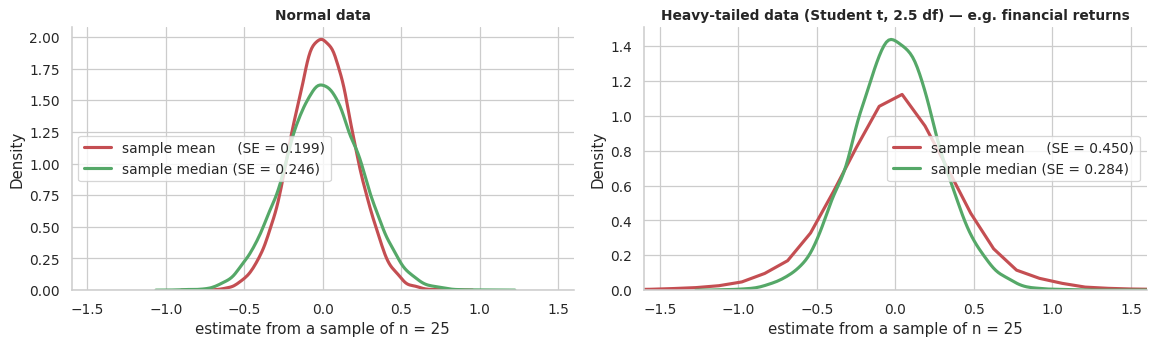

In [4]:
R, n = 20_000, 25
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
populations = {"Normal data": lambda size: rng.normal(0, 1, size),
               "Heavy-tailed data (Student t, 2.5 df) — e.g. financial returns": lambda size: rng.standard_t(2.5, size)}
for ax, (name, draw) in zip(axes, populations.items()):
    x = draw((R, n)); means, medians = x.mean(axis=1), np.median(x, axis=1)
    sns.kdeplot(means, ax=ax, color=C[3], lw=2.5, label=f"sample mean     (SE = {means.std():.3f})")
    sns.kdeplot(medians, ax=ax, color=C[2], lw=2.5, label=f"sample median (SE = {medians.std():.3f})")
    ax.set(title=name, xlabel=f"estimate from a sample of n = {n}", xlim=(-1.6, 1.6)); ax.title.set_fontsize(11); ax.legend()
plt.tight_layout(); plt.show()

**Reading the figure.** For normal data the mean is the **efficient** estimator: the median needs about 57 % more observations for the same precision ($\text{SE}_{median} \approx 1.25\,\sigma/\sqrt n$). With heavy tails the ranking flips — a few wild observations wreck the mean but not the median. There is no universally best estimator; the best one depends on the data-generating process. That is exactly what the next idea formalises.

---
## 3. Maximum likelihood — "which parameter makes my data least surprising?"

Assume a model with density $f(x \mid \theta)$. For observed data $x_1,\dots,x_n$ (independent) the **likelihood** is the joint density read *as a function of the parameter*:

$$L(\theta) = \prod_{i=1}^n f(x_i \mid \theta), \qquad \ell(\theta) = \log L(\theta) = \sum_{i=1}^n \log f(x_i\mid\theta).$$

The **maximum-likelihood estimate (MLE)** $\hat\theta$ maximises $\ell(\theta)$. We use the log because sums are easier than products and tiny probabilities underflow.

**Worked derivation (exponential waiting times, rate $\lambda$).** $f(x\mid\lambda) = \lambda e^{-\lambda x}$, so $\ell(\lambda) = n\log\lambda - \lambda\sum x_i$. Setting $\ell'(\lambda) = n/\lambda - \sum x_i = 0$ gives $\hat\lambda = 1/\bar x$. Likewise: Bernoulli $\hat p = k/n$; Poisson $\hat\lambda = \bar x$; Normal $\hat\mu = \bar x$, $\hat\sigma^2 = \frac1n\sum(x_i-\bar x)^2$ (note: the biased version!).

**Why statisticians love the MLE:** for large $n$ it is consistent, approximately normal, and has the smallest possible variance (it attains the Cramér–Rao bound). The **curvature** of $\ell$ at its peak measures information: a sharp peak means a precise estimate, $\operatorname{SE}(\hat\theta) \approx 1/\sqrt{-\ell''(\hat\theta)}$.

> ⚠️ A likelihood is **not** a probability distribution for $\theta$ — it does not integrate to 1. Turning it into one requires a prior (Module 12, Bayesian statistics).

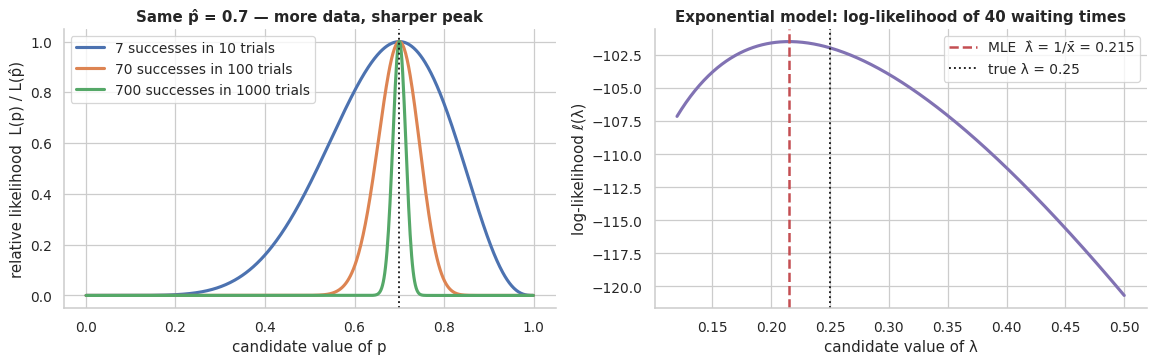

In [5]:
p = np.linspace(.001, .999, 600)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2))
for (k, n), col in zip([(7, 10), (70, 100), (700, 1000)], [C[0], C[1], C[2]]):
    L = stats.binom.pmf(k, n, p)
    a1.plot(p, L / L.max(), color=col, lw=2.5, label=f"{k} successes in {n} trials")
a1.axvline(.7, color="k", ls=":"); a1.legend()
a1.set(xlabel="candidate value of p", ylabel="relative likelihood  L(p) / L(p̂)", title="Same p̂ = 0.7 — more data, sharper peak")

wait = rng.exponential(scale=4.0, size=40)                 # 40 waiting times, true rate λ = 0.25 per minute
lam = np.linspace(.12, .5, 400)
a2.plot(lam, len(wait) * np.log(lam) - lam * wait.sum(), color=C[4], lw=2.5)
a2.axvline(1 / wait.mean(), color=C[3], ls="--", lw=2, label=f"MLE  λ̂ = 1/x̄ = {1 / wait.mean():.3f}")
a2.axvline(.25, color="k", ls=":", label="true λ = 0.25")
a2.set(xlabel="candidate value of λ", ylabel="log-likelihood ℓ(λ)", title="Exponential model: log-likelihood of 40 waiting times"); a2.legend()
plt.tight_layout(); plt.show()

### 3.1 Numerical maximum likelihood

Most real models have no closed-form solution. Then we hand the **negative** log-likelihood to an optimiser. We practise on a case where we know the answer (normal model), so we can check the machinery. Trick: optimise over $\log\sigma$ so that $\sigma>0$ is guaranteed.

numerical MLE : mu = 169.482, sigma = 7.988
closed form   : mu = 169.482, sigma = 7.988   (ddof=0 — the MLE of sigma is the biased one)


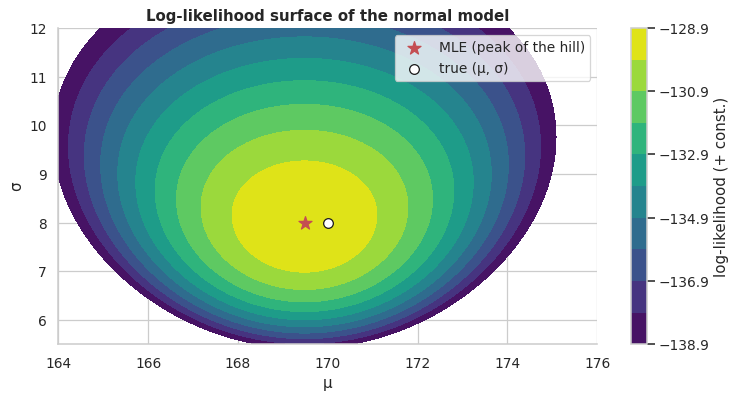

In [6]:
heights = rng.normal(170, 8, 50)

def neg_loglik(theta):
    mu, log_sigma = theta
    return -stats.norm.logpdf(heights, loc=mu, scale=np.exp(log_sigma)).sum()

fit = minimize(neg_loglik, x0=[150, np.log(20)], method="Nelder-Mead")
mu_hat, sigma_hat = fit.x[0], np.exp(fit.x[1])
print(f"numerical MLE : mu = {mu_hat:.3f}, sigma = {sigma_hat:.3f}")
print(f"closed form   : mu = {heights.mean():.3f}, sigma = {heights.std(ddof=0):.3f}   (ddof=0 — the MLE of sigma is the biased one)")

M, S = np.meshgrid(np.linspace(164, 176, 150), np.linspace(5.5, 12, 150))
LL = -heights.size * np.log(S) - ((heights[:, None, None] - M) ** 2).sum(axis=0) / (2 * S ** 2)
fig, ax = plt.subplots(figsize=(8.5, 4.6))
cs = ax.contourf(M, S, LL, levels=np.linspace(LL.max() - 10, LL.max(), 11), cmap="viridis"); plt.colorbar(cs, label="log-likelihood (+ const.)")
ax.scatter(mu_hat, sigma_hat, color=C[3], s=120, marker="*", zorder=3, label="MLE (peak of the hill)")
ax.scatter(170, 8, color="white", edgecolor="k", s=60, zorder=3, label="true (μ, σ)")
ax.set(xlabel="μ", ylabel="σ", title="Log-likelihood surface of the normal model"); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

---
## 4. Confidence interval for a mean

A point estimate without a margin of error is a rumour. From Module 4 we know $\bar X \approx N(\mu, \sigma^2/n)$. Replacing the unknown $\sigma$ by the sample value $s$ adds extra uncertainty, which the **Student $t$ distribution** accounts for:

$$\bar x \;\pm\; t_{1-\alpha/2,\;n-1}\cdot\frac{s}{\sqrt n}$$

Three ingredients determine the width: the **confidence level** (via $t$), the **noise** in the data ($s$) and the **sample size** ($\sqrt n$ — to halve the width you need four times the data).

### 4.1 What does "95 % confidence" mean?

The parameter $\mu$ is fixed; the *interval* is random. "95 %" is a property of the **procedure**: if we repeated the study many times, about 95 % of the intervals produced this way would cover $\mu$. For one concrete interval, $\mu$ is either inside or not — we just do not know which.

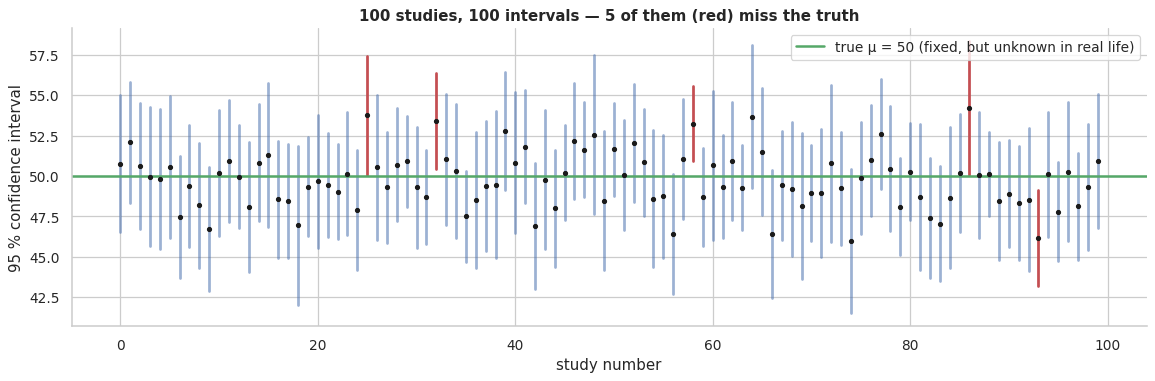

In [7]:
mu, sigma, n, reps = 50, 10, 30, 100
samples = rng.normal(mu, sigma, size=(reps, n))
m, se = samples.mean(axis=1), samples.std(axis=1, ddof=1) / np.sqrt(n)
tcrit = stats.t.ppf(.975, df=n - 1)
lo, hi = m - tcrit * se, m + tcrit * se
miss = (lo > mu) | (hi < mu)

fig, ax = plt.subplots(figsize=(13, 4.4))
for i in range(reps):
    ax.plot([i, i], [lo[i], hi[i]], color=C[3] if miss[i] else C[0], lw=2.2, alpha=1 if miss[i] else .55)
ax.scatter(range(reps), m, s=10, color="k", zorder=3)
ax.axhline(mu, color=C[2], lw=2, label="true μ = 50 (fixed, but unknown in real life)")
ax.set(xlabel="study number", ylabel="95 % confidence interval", title=f"100 studies, 100 intervals — {miss.sum()} of them (red) miss the truth"); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

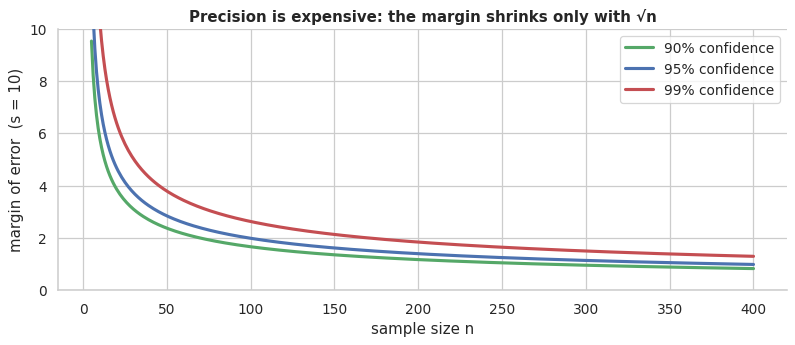

In [8]:
ns = np.arange(5, 401); s = 10
fig, ax = plt.subplots(figsize=(9, 4))
for level, col in zip([.90, .95, .99], [C[2], C[0], C[3]]):
    ax.plot(ns, stats.t.ppf(.5 + level / 2, ns - 1) * s / np.sqrt(ns), color=col, lw=2.5, label=f"{level:.0%} confidence")
ax.set(xlabel="sample size n", ylabel="margin of error  (s = 10)", ylim=(0, 10), title="Precision is expensive: the margin shrinks only with √n"); ax.legend()
plt.tight_layout(); plt.show()

**Sample-size planning.** Solving the margin of error $E = z\,\sigma/\sqrt n$ for $n$ gives $n = (z\,\sigma/E)^2$. You need a guess for $\sigma$ (pilot study, literature). Note the diminishing returns in the figure: going from $n=25$ to $n=100$ halves the margin; the next halving costs 300 additional observations.

---
## 5. Confidence interval for a proportion — Wald vs. Wilson

For $k$ successes in $n$ trials, $\hat p = k/n$ with $\operatorname{SE} = \sqrt{\hat p(1-\hat p)/n}$. The textbook **Wald interval** $\hat p \pm z\cdot \operatorname{SE}$ is simple — and surprisingly bad: for small $n$ or $p$ near 0 or 1 it covers the truth far less often than advertised, and for $k=0$ it collapses to the absurd interval $[0, 0]$.

Better alternatives:
* **Wilson score interval** — inverts the test instead of plugging in $\hat p$; works well even for small $n$. *Use this by default.*
* **Clopper–Pearson ("exact")** — guaranteed coverage $\ge 95\,\%$, therefore conservative (wide).
* **Rule of three** — if you observe **0 events in $n$ trials**, an approximate 95 % upper bound for $p$ is $3/n$.

Because the binomial distribution is known exactly, we can compute the **true coverage** of each method for every $p$ without simulation.

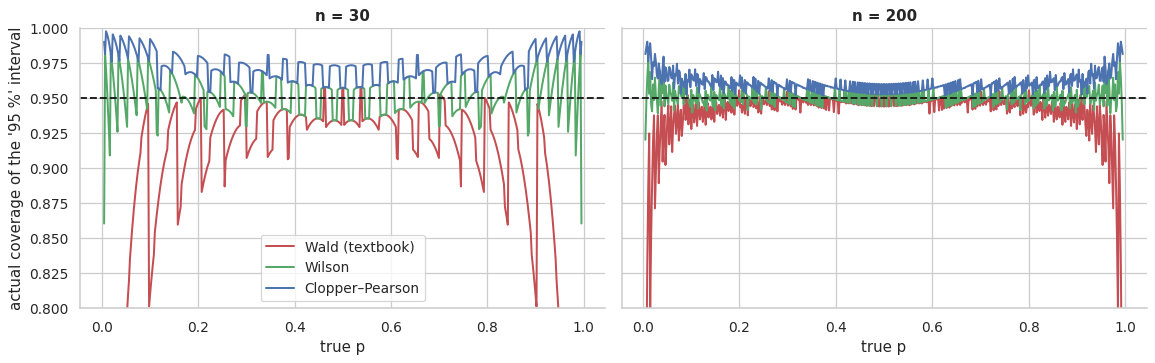

In [9]:
def true_coverage(n, p_grid, method):
    k = np.arange(n + 1)
    lo, hi = proportion_confint(k, n, alpha=.05, method=method)
    return np.array([stats.binom.pmf(k, n, p)[(lo <= p) & (p <= hi)].sum() for p in p_grid])

p_grid = np.linspace(.005, .995, 500)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, n in zip(axes, [30, 200]):
    for method, lab, col in [("normal", "Wald (textbook)", C[3]), ("wilson", "Wilson", C[2]), ("beta", "Clopper–Pearson", C[0])]:
        ax.plot(p_grid, true_coverage(n, p_grid, method), color=col, lw=1.6, label=lab)
    ax.axhline(.95, color="k", ls="--"); ax.set(title=f"n = {n}", xlabel="true p", ylim=(.80, 1.0))
axes[0].set_ylabel("actual coverage of the '95 %' interval"); axes[0].legend(loc="lower center")
plt.tight_layout(); plt.show()

**Reading the figure.** The dashed line is the promise (95 %). Wald (red) breaks it almost everywhere for $n=30$ and still does near the edges for $n=200$. Wilson oscillates *around* 95 %; Clopper–Pearson stays *above* it. The saw-tooth pattern comes from the discreteness of the binomial distribution.

---
## 6. Confidence intervals for differences between groups

Most practical questions are comparisons: *new vs. old*, *treated vs. control*. For independent groups the variances of the two estimates add:

| Comparison | Estimate | Standard error |
|---|---|---|
| two means (Welch) | $\bar x_1 - \bar x_2$ | $\sqrt{s_1^2/n_1 + s_2^2/n_2}$, with Welch–Satterthwaite degrees of freedom |
| two proportions | $\hat p_1 - \hat p_2$ | $\sqrt{\hat p_1(1-\hat p_1)/n_1 + \hat p_2(1-\hat p_2)/n_2}$ |

An interval for the difference answers two questions at once: *is there an effect?* (does the interval exclude 0?) and *how large could it plausibly be?* — far more useful than a bare p-value (Module 6).

difference new − old = -8.38 s,  SE = 2.87,  df = 92.6,  95 % CI = [-14.07, -2.68]


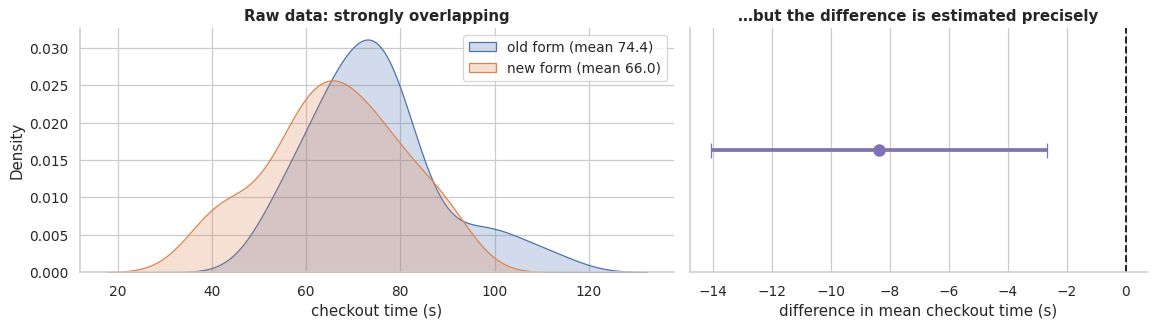

In [10]:
old = rng.normal(72, 12, 45)      # checkout time (s) with the old form
new = rng.normal(66, 14, 50)      # … with the new form
diff = new.mean() - old.mean()
v1, v2 = new.var(ddof=1) / new.size, old.var(ddof=1) / old.size
se = np.sqrt(v1 + v2)
df = (v1 + v2) ** 2 / (v1 ** 2 / (new.size - 1) + v2 ** 2 / (old.size - 1))          # Welch–Satterthwaite
lo, hi = diff + np.array([-1, 1]) * stats.t.ppf(.975, df) * se
print(f"difference new − old = {diff:.2f} s,  SE = {se:.2f},  df = {df:.1f},  95 % CI = [{lo:.2f}, {hi:.2f}]")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [1.3, 1]})
sns.kdeplot(old, ax=a1, fill=True, color=C[0], label=f"old form (mean {old.mean():.1f})"); sns.kdeplot(new, ax=a1, fill=True, color=C[1], label=f"new form (mean {new.mean():.1f})")
a1.set(title="Raw data: strongly overlapping", xlabel="checkout time (s)"); a1.legend()
a2.errorbar([diff], [0], xerr=[[diff - lo], [hi - diff]], fmt="o", color=C[4], capsize=6, lw=3, ms=9)
a2.axvline(0, color="k", ls="--"); a2.set(yticks=[], xlabel="difference in mean checkout time (s)", title="…but the difference is estimated precisely")
plt.tight_layout(); plt.show()

---
## 7. The bootstrap — confidence intervals without formulas

What is the standard error of a median, a 90th percentile, a ratio of means, a Gini coefficient? Formulas are messy or non-existent. The **bootstrap** (Efron, 1979) replaces mathematics by computation:

1. Treat the sample as a stand-in for the population.
2. Draw $B$ **resamples of size $n$ with replacement** from the sample.
3. Compute the statistic on each resample → the *bootstrap distribution*.
4. Its standard deviation estimates the SE; its 2.5 % and 97.5 % quantiles form the **percentile interval**.

It works because the variation of resamples around the sample mimics the variation of samples around the population. Below we can verify this, because in a simulation we *can* draw fresh samples from the real population.

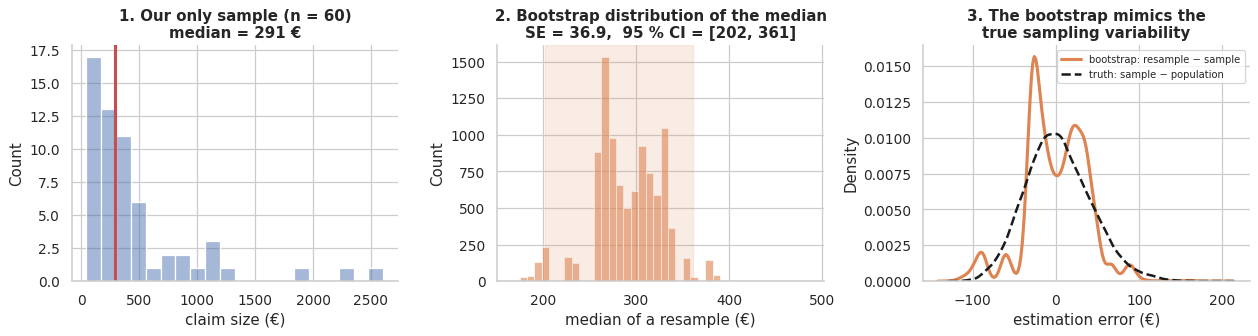

percentile interval: [202, 361]   BCa interval (scipy): [203, 375]   true population median: 300


In [11]:
population = stats.lognorm(s=.8, scale=300)                  # claim sizes (€); in real life this is unknown
sample = population.rvs(60, random_state=rng)                # the ONE sample we actually have
B = 10_000
boot = np.median(rng.choice(sample, size=(B, sample.size), replace=True), axis=1)          # resampling the sample
truth = np.median(population.rvs((B, sample.size), random_state=rng), axis=1)              # resampling the population
lo, hi = np.quantile(boot, [.025, .975])

fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))
sns.histplot(sample, bins=20, ax=axes[0], color=C[0], alpha=.5); axes[0].axvline(np.median(sample), color=C[3], lw=2.5)
axes[0].set(title=f"1. Our only sample (n = 60)\nmedian = {np.median(sample):.0f} €", xlabel="claim size (€)")
sns.histplot(boot, bins=40, ax=axes[1], color=C[1], alpha=.6); axes[1].axvspan(lo, hi, color=C[1], alpha=.15)
axes[1].set(title=f"2. Bootstrap distribution of the median\nSE = {boot.std():.1f},  95 % CI = [{lo:.0f}, {hi:.0f}]", xlabel="median of a resample (€)")
sns.kdeplot(boot - np.median(sample), ax=axes[2], color=C[1], lw=2.5, label="bootstrap: resample − sample")
sns.kdeplot(truth - population.median(), ax=axes[2], color="k", lw=2, ls="--", label="truth: sample − population")
axes[2].set(title="3. The bootstrap mimics the\ntrue sampling variability", xlabel="estimation error (€)"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

bca = stats.bootstrap((sample,), np.median, n_resamples=9999, method="BCa", random_state=1).confidence_interval
print(f"percentile interval: [{lo:.0f}, {hi:.0f}]   BCa interval (scipy): [{bca.low:.0f}, {bca.high:.0f}]   true population median: {population.median():.0f}")

**Practical notes.** Use $B \ge 2{,}000$ for intervals. The **BCa** interval (bias-corrected and accelerated, `scipy.stats.bootstrap`) corrects the percentile interval for bias and skewness and is the better default. The bootstrap is no magic: it cannot repair a **biased sample**, struggles with very small $n$ (< 15–20) and with extremes (max, min), and must respect the data structure (resample *pairs*, *clusters* or *blocks* if the observations are paired, clustered or serially correlated).

---
## 8. Confidence interval vs. prediction interval — do not mix them up

* A **confidence interval** is about a *parameter* (e.g. the mean delivery time). It shrinks to zero width as $n\to\infty$.
* A **prediction interval** is about *one future observation* (the delivery time of *your* parcel). It can never be narrower than the natural scatter of the data: for normal data $\bar x \pm t\cdot s\sqrt{1 + 1/n}$.

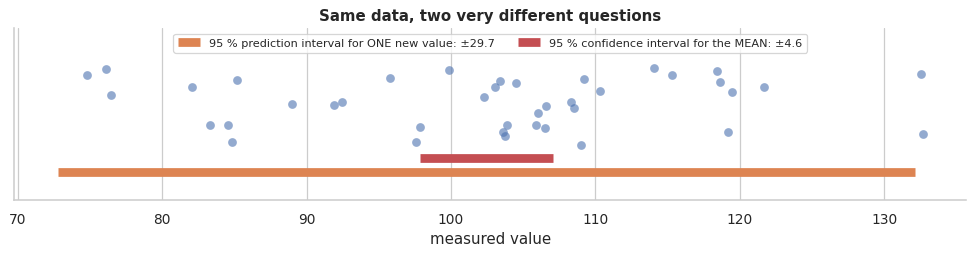

In [12]:
x = rng.normal(100, 15, 40); m, s, n = x.mean(), x.std(ddof=1), x.size; t = stats.t.ppf(.975, n - 1)
ci, pi = t * s / np.sqrt(n), t * s * np.sqrt(1 + 1 / n)
fig, ax = plt.subplots(figsize=(11, 3))
sns.stripplot(x=x, ax=ax, color=C[0], alpha=.6, size=7, jitter=.25)
ax.plot([m - pi, m + pi], [.42, .42], color=C[1], lw=7, solid_capstyle="butt", label=f"95 % prediction interval for ONE new value: ±{pi:.1f}")
ax.plot([m - ci, m + ci], [.33, .33], color=C[3], lw=7, solid_capstyle="butt", label=f"95 % confidence interval for the MEAN: ±{ci:.1f}")
ax.set(ylim=(.6, -.5), xlabel="measured value", title="Same data, two very different questions"); ax.legend(loc="upper center", ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

### Common misreadings of a confidence interval

| Statement | Verdict |
|---|---|
| "There is a 95 % probability that $\mu$ lies in [48.1, 53.4]." | ✗ (frequentist) — $\mu$ is fixed; the *procedure* succeeds in 95 % of studies. A probability statement about $\mu$ needs a Bayesian *credible* interval (Module 12). |
| "95 % of the data lie in the interval." | ✗ — that would be a tolerance/prediction-type statement. |
| "If I repeat the study, the new mean falls in this interval with 95 % probability." | ✗ — that probability is only about 83 %. |
| "Values outside the interval are implausible given the data; values inside are compatible with it." | ✓ a sound practical reading. |

---
## 9. Exercises — real-world use cases
Each exercise is self-contained. Run the data cell, then work in the empty cell below it.

### ✍️ Exercise 5.1 — *Bias, variance, MSE*: The German tank problem (Intelligence / competitive analysis)

In World War II the Allies estimated German tank production from the **serial numbers** of captured tanks — and the statisticians' estimates turned out to be far more accurate than those of conventional intelligence. Analysts use the same idea today to estimate a competitor's production volume from serial numbers of purchased devices.

Assume items are numbered $1,\dots,N$ and we observe $k$ serial numbers drawn at random without replacement. $N$ is unknown.

**Tasks**
1. For the captured `serials`, compute three candidate estimators: (a) $2\bar x - 1$, (b) the sample maximum $m$, (c) $m\,(1 + 1/k) - 1$.
2. Simulate 10,000 captures (same $N$ and $k$) and compare **bias, standard deviation and RMSE** of the three estimators. Plot their sampling distributions.
3. Why is (b) biased? Why is (c) so much better than (a), although both are unbiased?

In [13]:
g = np.random.default_rng(501)
N_true, k = 1380, 12                       # N_true is what the analyst wants to know
serials = np.sort(g.choice(np.arange(1, N_true + 1), size=k, replace=False))
print("captured serial numbers:", serials)

captured serial numbers: [  20  576  593  611  617  770  878 1044 1187 1232 1366 1371]


In [14]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/05_estimation_confidence_intervals_solutions.ipynb`.

### ✍️ Exercise 5.2 — *Maximum likelihood*: How long do subscribers stay? (Subscription business / survival analysis)

A streaming service wants the **average customer lifetime**. The catch: many customers are still active — for them we only know that their lifetime is *at least* their current tenure (**right-censoring**). Averaging the lifetimes of the churned customers only is badly biased, because short lifetimes are over-represented among those already gone.

Assume exponential lifetimes with churn rate $\lambda$ (mean lifetime $1/\lambda$). A churned customer contributes the density $f(t)=\lambda e^{-\lambda t}$ to the likelihood, a still-active customer contributes the survival probability $S(t)=e^{-\lambda t}$:

$$\ell(\lambda) = \sum_{\text{churned}} \log\big(\lambda e^{-\lambda t_i}\big) + \sum_{\text{active}} \log\big(e^{-\lambda t_i}\big) = d\,\log\lambda - \lambda \sum_{\text{all}} t_i \qquad (d = \text{number of churned customers})$$

**Tasks**
1. Compute the naive estimate: mean observed lifetime of churned customers.
2. Code the censored log-likelihood, maximise it numerically (`minimize_scalar`) and compare with the closed form $\hat\lambda = d / \sum t_i$.
3. Plot $\ell(\lambda)$ and mark the MLE and the naive estimate.
4. Give a 95 % CI for the mean lifetime using $\operatorname{SE}(\hat\lambda) \approx \hat\lambda/\sqrt d$.
5. Estimate the 12-month retention rate $S(12)$.

In [15]:
g = np.random.default_rng(502)
n = 800
lifetime = g.exponential(14.0, n)                      # true mean lifetime: 14 months (unknown to the analyst)
tenure_limit = g.uniform(1, 18, n)                     # months since sign-up = how long we could observe each customer
subs = pd.DataFrame({"months_observed": np.minimum(lifetime, tenure_limit).round(2),
                     "churned": (lifetime <= tenure_limit).astype(int)})
print(subs.churned.value_counts().rename({1: "churned", 0: "still active (censored)"})); subs.head()

churned
still active (censored)    439
churned                    361
Name: count, dtype: int64


,months_observed,churned
0,3.41,1
1,4.32,0
2,6.76,0
3,8.50,0
4,8.69,0


In [16]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/05_estimation_confidence_intervals_solutions.ipynb`.

### ✍️ Exercise 5.3 — *CI for a mean & sample-size planning*: What is the average basket value? (Retail controlling)

A supermarket chain audits a random sample of 80 receipts from one store. Headquarters claims that "the average basket is worth €50".

**Tasks**
1. Compute the 95 % CI for the mean basket value by hand ($\bar x \pm t\cdot s/\sqrt n$) and check it with `stats.t.interval`.
2. The data is right-skewed. Validate the $t$-interval with a bootstrap percentile interval.
3. Is the headquarters' claim compatible with the data?
4. How many receipts are needed for a margin of error of ±€2 (95 %)?

In [17]:
g = np.random.default_rng(503)
basket = pd.Series(g.gamma(shape=2.2, scale=19, size=80).round(2), name="basket_eur")
basket.describe().round(2)

count     80.00
mean      39.92
std       28.45
min        3.03
25%       20.52
50%       33.68
75%       51.49
max      157.99
Name: basket_eur, dtype: float64

In [18]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/05_estimation_confidence_intervals_solutions.ipynb`.

### ✍️ Exercise 5.4 — *CI for a proportion*: Satisfaction rates and "zero defects" (Quality management)

**(a)** In a customer survey 412 of 500 respondents are satisfied. **(b)** A supplier delivers a first batch; you inspect 60 units and find **no defective unit**. The supplier concludes: "our defect rate is 0 %".

**Tasks**
1. For (a), compute the Wald and the Wilson 95 % interval. Do they differ much? Why (not)?
2. For (b), compute Wald, Wilson and Clopper–Pearson intervals and compare the upper limits with the *rule of three*.
3. How many consecutive defect-free units would you need to inspect to claim "defect rate below 1 %" with 95 % confidence?

In [19]:
k_a, n_a = 412, 500       # (a) satisfied customers
k_b, n_b = 0, 60          # (b) defective units

In [20]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/05_estimation_confidence_intervals_solutions.ipynb`.

### ✍️ Exercise 5.5 — *Bootstrap*: Did the new recommendation engine lift revenue per visitor? (E-commerce A/B test)

Revenue per visitor is a nasty metric: ~95 % of visitors buy nothing (zeros) and buyers' spend is heavily right-skewed. Management wants the **relative lift** $\;(\bar x_{variant} - \bar x_{control})/\bar x_{control}$ with an uncertainty statement. There is no simple formula for the CI of such a ratio — a job for the bootstrap.

**Tasks**
1. Compute revenue per visitor in both groups and the observed relative lift.
2. Bootstrap the relative lift (resample **each group separately**, $B = 4{,}000$) and report the 95 % percentile interval.
3. Plot the bootstrap distribution. In what share of resamples is the lift positive?
4. What do you tell management?

In [21]:
g = np.random.default_rng(505)
def simulate_revenue(n, p_buy, mu):                          # most visitors buy nothing; buyers spend a log-normal amount
    return np.where(g.random(n) < p_buy, g.lognormal(mu, 1.0, n), 0).round(2)
control, variant = simulate_revenue(12_000, .050, 3.60), simulate_revenue(12_000, .056, 3.65)
print(f"buyers: control {np.mean(control > 0):.2%}, variant {np.mean(variant > 0):.2%};  largest single order: {max(control.max(), variant.max()):,.0f} €")

buyers: control 4.97%, variant 5.51%;  largest single order: 767 €


In [22]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/05_estimation_confidence_intervals_solutions.ipynb`.

---
## 10. 🔑 Key takeaways

* Judge estimators by their **sampling distribution**: $\text{MSE} = \text{bias}^2 + \text{variance}$. Unbiased is nice, low MSE is what matters.
* Dividing by $n-1$ makes $s^2$ unbiased because one degree of freedom is spent on $\bar x$.
* **Maximum likelihood** is the general-purpose construction principle: write down the model, maximise $\ell(\theta)$ — analytically or numerically. It handles censoring and other partial information gracefully.
* A **95 % CI** is produced by a procedure that captures the truth in 95 % of studies. Width $\propto s/\sqrt n$ → quadruple the data to halve the margin.
* For proportions prefer **Wilson** over Wald; for zero events remember the **rule of three** ($3/n$).
* The **bootstrap** delivers SEs and CIs for almost any statistic; prefer BCa, respect the data structure, and never expect it to cure biased sampling.
* **Prediction intervals** (one new observation) are much wider than confidence intervals (a parameter) and do not shrink to zero.

### Cheat sheet
| Task | Code |
|---|---|
| $t$-interval for a mean | `stats.t.interval(0.95, n-1, loc=x.mean(), scale=stats.sem(x))` |
| CI for a proportion | `proportion_confint(k, n, method="wilson")` (`"normal"` = Wald, `"beta"` = Clopper–Pearson) |
| Welch CI for a difference | `stats.ttest_ind(a, b, equal_var=False).confidence_interval()` |
| fit a distribution by ML | `stats.gamma.fit(x, floc=0)`; custom model: `scipy.optimize.minimize(neg_loglik, x0)` |
| bootstrap CI | `stats.bootstrap((x,), np.median, method="BCa").confidence_interval` |
| manual bootstrap | `rng.choice(x, size=(B, x.size), replace=True)` → statistic along `axis=1` |
| sample size for margin $E$ | $n = (z\,\sigma/E)^2$ (mean) · $n = z^2\,p(1-p)/E^2$ (proportion) |

**Next:** Module 6 — hypothesis testing: from intervals to decisions, error rates and power.